In [2]:
import tqdm
import random
import pathlib
import itertools
import collections
import math

import cv2
import einops
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers
from sklearn.model_selection import train_test_split

HEIGHT = 224
WIDTH = 224
FRAMES_PER_VIDEO = 10
OVERLAP = 0  # Перекрытие между последовательностями (можно менять)

class Conv2Plus1D(keras.layers.Layer):
    def __init__(self, filters, kernel_size, padding, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.padding = padding
        
        self.seq = keras.Sequential([  
            layers.Conv3D(filters=filters,
                         kernel_size=(1, kernel_size[1], kernel_size[2]),
                         padding=padding),
            layers.Conv3D(filters=filters, 
                         kernel_size=(kernel_size[0], 1, 1),
                         padding=padding)
        ])

    def call(self, x):
        return self.seq(x)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'filters': self.filters,
            'kernel_size': self.kernel_size,
            'padding': self.padding
        })
        return config

class ResidualMain(keras.layers.Layer):
    def __init__(self, filters, kernel_size, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        
        self.seq = keras.Sequential([
            Conv2Plus1D(filters=filters,
                       kernel_size=kernel_size,
                       padding='same'),
            layers.LayerNormalization(),
            layers.ReLU(),
            Conv2Plus1D(filters=filters, 
                       kernel_size=kernel_size,
                       padding='same'),
            layers.LayerNormalization()
        ])

    def call(self, x):
        return self.seq(x)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'filters': self.filters,
            'kernel_size': self.kernel_size
        })
        return config

class Project(keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        
        self.seq = keras.Sequential([
            layers.Dense(units),
            layers.LayerNormalization()
        ])

    def call(self, x):
        return self.seq(x)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units
        })
        return config

class ResizeVideo(keras.layers.Layer):
    def __init__(self, height, width, **kwargs):
        super().__init__(**kwargs)
        self.height = height
        self.width = width
        self.resizing_layer = layers.Resizing(self.height, self.width)

    def call(self, video):
        old_shape = einops.parse_shape(video, 'b t h w c')
        images = einops.rearrange(video, 'b t h w c -> (b t) h w c')
        images = self.resizing_layer(images)
        videos = einops.rearrange(
            images, '(b t) h w c -> b t h w c',
            t=old_shape['t'])
        return videos
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'height': self.height,
            'width': self.width
        })
        return config

def add_residual_block(input, filters, kernel_size):
    out = ResidualMain(filters, kernel_size)(input)

    res = input
    if out.shape[-1] != input.shape[-1]:
        res = Project(out.shape[-1])(res)

    return layers.add([res, out])

class FrameSequenceGenerator(keras.utils.Sequence):
    def __init__(self, data_dir, batch_size=32, frames_per_sequence=FRAMES_PER_VIDEO, 
                 img_size=(HEIGHT, WIDTH), shuffle=True, is_train=True, overlap=OVERLAP, preprocess_function=None):
        self.data_dir = pathlib.Path(data_dir)
        self.batch_size = batch_size
        self.frames_per_sequence = frames_per_sequence
        self.img_size = img_size
        self.shuffle = shuffle
        self.is_train = is_train
        self.overlap = overlap
        self.preprocess_function=preprocess_function
        # Собираем все изображения из папок
        self.sequences = self._prepare_sequences()
        
        self.indexes = np.arange(len(self.sequences))
        if self.shuffle:
            np.random.shuffle(self.indexes)
        
        print(f"Found {len(self.sequences)} sequences")
        print(f"Real: {len([s for s in self.sequences if s['label'] == 0])}")
        print(f"Fake: {len([s for s in self.sequences if s['label'] == 1])}")
    
    def _prepare_sequences(self):
        sequences = []
        
        # Обрабатываем реальные кадры
        real_dir = self.data_dir / 'real'
        if real_dir.exists():
            real_images = sorted(list(real_dir.glob('*.jpg')) + 
                               list(real_dir.glob('*.png')) +
                               list(real_dir.glob('*.jpeg')))
            print(f"Found {len(real_images)} real images")
            
            # Разбиваем на последовательности с перекрытием
            if len(real_images) >= self.frames_per_sequence:
                step = self.frames_per_sequence - self.overlap
                for i in range(0, len(real_images) - self.frames_per_sequence + 1, max(1, step)):
                    sequence_frames = real_images[i:i + self.frames_per_sequence]
                    sequences.append({
                        'frames': sequence_frames,
                        'label': 0  # real
                    })
        else:
            print(f"Warning: Real directory {real_dir} does not exist!")
        
        # Обрабатываем фейковые кадры
        fake_dir = self.data_dir / 'fake'
        if fake_dir.exists():
            fake_images = sorted(list(fake_dir.glob('*.jpg')) + 
                               list(fake_dir.glob('*.png')) +
                               list(fake_dir.glob('*.jpeg')))
            print(f"Found {len(fake_images)} fake images")
            
            # Разбиваем на последовательности с перекрытием
            if len(fake_images) >= self.frames_per_sequence:
                step = self.frames_per_sequence - self.overlap
                for i in range(0, len(fake_images) - self.frames_per_sequence + 1, max(1, step)):
                    sequence_frames = fake_images[i:i + self.frames_per_sequence]
                    sequences.append({
                        'frames': sequence_frames,
                        'label': 1  # fake
                    })
        else:
            print(f"Warning: Fake directory {fake_dir} does not exist!")
        
        return sequences
    
    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))
    
    def __getitem__(self, index):
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, len(self.sequences))
        
        batch_indexes = self.indexes[start_idx:end_idx]
        batch_sequences = [self.sequences[i] for i in batch_indexes]
        
        X = np.zeros((len(batch_sequences), self.frames_per_sequence, 
                     self.img_size[0], self.img_size[1], 3), dtype=np.float32)
        y = np.zeros((len(batch_sequences), 1), dtype=np.float32)
        
        for i, seq in enumerate(batch_sequences):
            # Загружаем кадры
            for j, frame_path in enumerate(seq['frames']):
                try:
                    img = cv2.imread(str(frame_path))
                    if img is not None and self.preprocess_function == None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        img = cv2.resize(img, (self.img_size[1], self.img_size[0]))
                        X[i, j] = img / 255.0
                    elif self.preprocess_function != None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        img = cv2.resize(img, (self.img_size[1], self.img_size[0]))
                        img = self.preprocess_function(img)
                    else:
                        print(f"Warning: Could not load image {frame_path}")
                        # Заполняем нулями или предыдущим кадром
                        if j > 0:
                            X[i, j] = X[i, j-1]
                except Exception as e:
                    print(f"Error loading {frame_path}: {e}")
                    if j > 0:
                        X[i, j] = X[i, j-1]
            
            y[i] = seq['label']
        
        return X, y
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

def create_model():
    input_shape = (FRAMES_PER_VIDEO, HEIGHT, WIDTH, 3)
    input = layers.Input(shape=input_shape)
    x = input
    
    x = Conv2Plus1D(filters=16, kernel_size=(3, 7, 7), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = ResizeVideo(HEIGHT // 2, WIDTH // 2)(x)
    
    # Block 1
    x = add_residual_block(x, 16, (3, 3, 3))
    x = ResizeVideo(HEIGHT // 4, WIDTH // 4)(x)
    
    # Block 2
    x = add_residual_block(x, 32, (3, 3, 3))
    x = ResizeVideo(HEIGHT // 8, WIDTH // 8)(x)
    
    # Block 3
    x = add_residual_block(x, 64, (3, 3, 3))
    x = ResizeVideo(HEIGHT // 16, WIDTH // 16)(x)
    
    # Block 4
    x = add_residual_block(x, 128, (3, 3, 3))
    
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(1, activation='sigmoid')(x)  # Бинарная классификация
    
    model = keras.Model(input, x)
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall(), 
                keras.metrics.AUC(name='auc')]
    )
    
    return model

def create_balanced_generators():
    """Создает сбалансированные генераторы для train и test"""
    # Для обучения
    train_generator = FrameSequenceGenerator(
        data_dir='../balanced_data/train',
        batch_size=8,  # Уменьшил batch_size для экономии памяти
        frames_per_sequence=FRAMES_PER_VIDEO,
        img_size=(HEIGHT, WIDTH),
        shuffle=True,
        is_train=True,
        overlap=OVERLAP
    )
    
    # Для тестирования
    test_generator = FrameSequenceGenerator(
        data_dir='../balanced_data/test',
        batch_size=8,
        frames_per_sequence=FRAMES_PER_VIDEO,
        img_size=(HEIGHT, WIDTH),
        shuffle=False,
        is_train=False,
        overlap=0  # Без перекрытия для теста
    )
    
    return train_generator, test_generator

def train_model():
    # Создаем генераторы данных
    train_generator, test_generator = create_balanced_generators()
    
    # Создаем модель
    model = create_model()
    model.summary()
    
    # Callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6
        ),
        keras.callbacks.ModelCheckpoint(
            filepath='best_deepfake_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max'
        ),
        keras.callbacks.CSVLogger('training_log.csv')
    ]
    
    # Обучаем модель
    print("\nStarting training...")
    print(f"Train batches per epoch: {len(train_generator)}")
    print(f"Test batches per epoch: {len(test_generator)}")
    
    history = model.fit(
        train_generator,
        epochs=50,
        validation_data=test_generator,
        callbacks=callbacks,
        workers=2,  # Уменьшил количество workers
        use_multiprocessing=False,  # Отключил multiprocessing для отладки
        verbose=1
    )
    
    # Оценка модели
    print("\nEvaluating model on test data...")
    test_results = model.evaluate(test_generator)
    print(f"\nTest Results:")
    print(f"Loss: {test_results[0]:.4f}")
    print(f"Accuracy: {test_results[1]:.4f}")
    print(f"Precision: {test_results[2]:.4f}")
    print(f"Recall: {test_results[3]:.4f}")
    print(f"AUC: {test_results[4]:.4f}")
    
    # Визуализация результатов
    plot_training_history(history)
    
    return model, history

def plot_training_history(history):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Accuracy', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Loss', fontsize=12)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    if 'precision' in history.history:
        axes[0, 2].plot(history.history['precision'], label='Train Precision', linewidth=2)
        axes[0, 2].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
        axes[0, 2].set_title('Precision', fontsize=14, fontweight='bold')
        axes[0, 2].set_xlabel('Epoch', fontsize=12)
        axes[0, 2].set_ylabel('Precision', fontsize=12)
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)
    
    # Recall
    if 'recall' in history.history:
        axes[1, 0].plot(history.history['recall'], label='Train Recall', linewidth=2)
        axes[1, 0].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
        axes[1, 0].set_title('Recall', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch', fontsize=12)
        axes[1, 0].set_ylabel('Recall', fontsize=12)
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # AUC
    if 'auc' in history.history:
        axes[1, 1].plot(history.history['auc'], label='Train AUC', linewidth=2)
        axes[1, 1].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
        axes[1, 1].set_title('AUC', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch', fontsize=12)
        axes[1, 1].set_ylabel('AUC', fontsize=12)
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    # Learning Rate
    if 'lr' in history.history:
        axes[1, 2].plot(history.history['lr'], linewidth=2)
        axes[1, 2].set_title('Learning Rate', fontsize=14, fontweight='bold')
        axes[1, 2].set_xlabel('Epoch', fontsize=12)
        axes[1, 2].set_ylabel('Learning Rate', fontsize=12)
        axes[1, 2].grid(True, alpha=0.3)
        axes[1, 2].set_yscale('log')
    else:
        axes[1, 2].axis('off')
        axes[1, 2].text(0.5, 0.5, 'Learning Rate\nNot available', 
                       ha='center', va='center', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

def predict_sequence_from_folder(model, frames_folder, label="unknown"):
    """Предсказание для последовательности кадров из папки"""
    frames = sorted(list(pathlib.Path(frames_folder).glob('*.jpg')) + 
                   list(pathlib.Path(frames_folder).glob('*.png')) +
                   list(pathlib.Path(frames_folder).glob('*.jpeg')))
    
    if len(frames) < FRAMES_PER_VIDEO:
        print(f"Not enough frames. Need {FRAMES_PER_VIDEO}, got {len(frames)}")
        return None
    
    # Создаем несколько последовательностей из всех кадров
    predictions = []
    step = FRAMES_PER_VIDEO
    
    for i in range(0, len(frames) - FRAMES_PER_VIDEO + 1, step):
        sequence_frames = frames[i:i + FRAMES_PER_VIDEO]
        
        X = np.zeros((1, FRAMES_PER_VIDEO, HEIGHT, WIDTH, 3), dtype=np.float32)
        
        for j, frame_path in enumerate(sequence_frames):
            try:
                img = cv2.imread(str(frame_path))
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (WIDTH, HEIGHT))
                    X[0, j] = img / 255.0
                else:
                    if j > 0:
                        X[0, j] = X[0, j-1]
            except Exception as e:
                print(f"Error loading {frame_path}: {e}")
                if j > 0:
                    X[0, j] = X[0, j-1]
        
        prediction = model.predict(X, verbose=0)[0][0]
        predictions.append(prediction)
    
    if predictions:
        avg_prediction = np.mean(predictions)
        confidence = avg_prediction if avg_prediction > 0.5 else 1 - avg_prediction
        label_result = "FAKE" if avg_prediction > 0.5 else "REAL"
        
        return {
            'probability': float(avg_prediction),
            'label': label_result,
            'confidence': float(confidence),
            'individual_predictions': [float(p) for p in predictions],
            'actual_label': label
        }
    
    return None

def analyze_dataset():
    """Анализ набора данных"""
    print("Analyzing dataset structure...")
    
    train_dir = pathlib.Path('../balanced_data/train')
    test_dir = pathlib.Path('../balanced_data/test')
    
    for data_dir, name in [(train_dir, "TRAIN"), (test_dir, "TEST")]:
        print(f"\n{name} SET:")
        if data_dir.exists():
            real_dir = data_dir / 'real'
            fake_dir = data_dir / 'fake'
            
            if real_dir.exists():
                real_files = list(real_dir.glob('*.*'))
                print(f"  Real images: {len(real_files)}")
                
                # Проверяем форматы файлов
                real_extensions = collections.Counter([f.suffix.lower() for f in real_files])
                print(f"  Real file extensions: {dict(real_extensions)}")
                
                # Пример имен файлов
                if real_files:
                    print(f"  Example real files (first 5):")
                    for f in real_files[:5]:
                        print(f"    {f.name}")
            else:
                print(f"  Real directory does not exist: {real_dir}")
            
            if fake_dir.exists():
                fake_files = list(fake_dir.glob('*.*'))
                print(f"  Fake images: {len(fake_files)}")
                
                # Проверяем форматы файлов
                fake_extensions = collections.Counter([f.suffix.lower() for f in fake_files])
                print(f"  Fake file extensions: {dict(fake_extensions)}")
                
                # Пример имен файлов
                if fake_files:
                    print(f"  Example fake files (first 5):")
                    for f in fake_files[:5]:
                        print(f"    {f.name}")
            else:
                print(f"  Fake directory does not exist: {fake_dir}")
        else:
            print(f"  Directory {data_dir} does not exist!")

def test_generator():
    """Тестируем генератор"""
    print("\nTesting generator...")
    train_generator, _ = create_balanced_generators()
    
    if len(train_generator) > 0:
        X_batch, y_batch = train_generator[0]
        print(f"Batch shape: {X_batch.shape}")
        print(f"Labels shape: {y_batch.shape}")
        print(f"Unique labels: {np.unique(y_batch)}")
        print(f"Min/Max pixel values: {X_batch.min():.2f}, {X_batch.max():.2f}")
        
        # Показываем пример изображения
        plt.figure(figsize=(10, 5))
        for i in range(min(3, X_batch.shape[0])):
            plt.subplot(1, 3, i+1)
            plt.imshow(X_batch[i, 0])  # Первый кадр
            plt.title(f"Label: {'Fake' if y_batch[i,0] > 0.5 else 'Real'}")
            plt.axis('off')
        plt.tight_layout()
        plt.savefig('sample_frames.png', dpi=150)
        plt.show()
    else:
        print("Generator is empty!")

In [3]:

    # Устанавливаем seed для воспроизводимости
    np.random.seed(42)
    tf.random.set_seed(42)
    
    # Анализируем структуру данных
    analyze_dataset()

Analyzing dataset structure...

TRAIN SET:
  Real images: 15777
  Real file extensions: {'.png': 15777}
  Example real files (first 5):
    0.png
    1.png
    10.png
    100.png
    1000.png
  Fake images: 16000
  Fake file extensions: {'.png': 16000}
  Example fake files (first 5):
    1.png
    10001.png
    10005.png
    10007.png
    10010.png

TEST SET:
  Real images: 4469
  Real file extensions: {'.png': 4469}
  Example real files (first 5):
    0.png
    1.png
    10001.png
    10002.png
    10003.png
  Fake images: 4037
  Fake file extensions: {'.png': 4037}
  Example fake files (first 5):
    1.png
    1000.png
    1003.png
    1006.png
    1007.png


In [20]:
train_generator = FrameSequenceGenerator(
    data_dir='../balanced_data/train',
    batch_size=4,
    frames_per_sequence=FRAMES_PER_VIDEO,
    img_size=(HEIGHT, WIDTH),
    shuffle=True,
    is_train=True,
    overlap=OVERLAP
)
    
# Для тестирования
test_generator = FrameSequenceGenerator(
    data_dir='../balanced_data/test',
    batch_size=4,
    frames_per_sequence=FRAMES_PER_VIDEO,
    img_size=(HEIGHT, WIDTH),
    shuffle=True,
    is_train=False,
    overlap=0  # Без перекрытия для теста
)

Found 15777 real images
Found 16000 fake images
Found 3177 sequences
Real: 1577
Fake: 1600
Found 4469 real images
Found 4037 fake images
Found 849 sequences
Real: 446
Fake: 403


In [5]:
model = create_model()

In [6]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 10, 224, 22  0           []                               
                                4, 3)]                                                            
                                                                                                  
 conv2_plus1d (Conv2Plus1D)     (None, 10, 224, 224  3152        ['input_1[0][0]']                
                                , 16)                                                             
                                                                                                  
 batch_normalization (BatchNorm  (None, 10, 224, 224  64         ['conv2_plus1d[0][0]']           
 alization)                     , 16)                                                         

In [21]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),
#    keras.callbacks.ModelCheckpoint(
#        filepath='best_deepfake_model.keras',
#        monitor='val_accuracy',
#        save_best_only=True,
#        mode='max'
#    ),
#    keras.callbacks.CSVLogger('training_log.csv')
]

In [8]:
print("\nStarting training...")
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks,
    validation_steps=32,
    steps_per_epoch=256
)


Starting training...
Epoch 1/20
256/256 [==============================] - 262s 987ms/step - loss: 0.6357 - accuracy: 0.6787 - precision: 0.6793 - recall: 0.6925 - auc: 0.7233 - val_loss: 0.8524 - val_accuracy: 0.5156 - val_precision: 0.4576 - val_recall: 0.4737 - val_auc: 0.5111 - lr: 1.0000e-04
Epoch 2/20
256/256 [==============================] - 230s 898ms/step - loss: 0.5098 - accuracy: 0.7861 - precision: 0.7660 - recall: 0.8324 - auc: 0.8370 - val_loss: 1.0726 - val_accuracy: 0.5078 - val_precision: 0.4727 - val_recall: 0.4333 - val_auc: 0.5147 - lr: 1.0000e-04
Epoch 3/20
256/256 [==============================] - 231s 900ms/step - loss: 0.5292 - accuracy: 0.7852 - precision: 0.7710 - recall: 0.7928 - auc: 0.8287 - val_loss: 0.8794 - val_accuracy: 0.5234 - val_precision: 0.4815 - val_recall: 0.4407 - val_auc: 0.5450 - lr: 1.0000e-04
Epoch 4/20
256/256 [==============================] - 223s 869ms/step - loss: 0.4676 - accuracy: 0.8047 - precision: 0.7950 - recall: 0.8399 - auc:

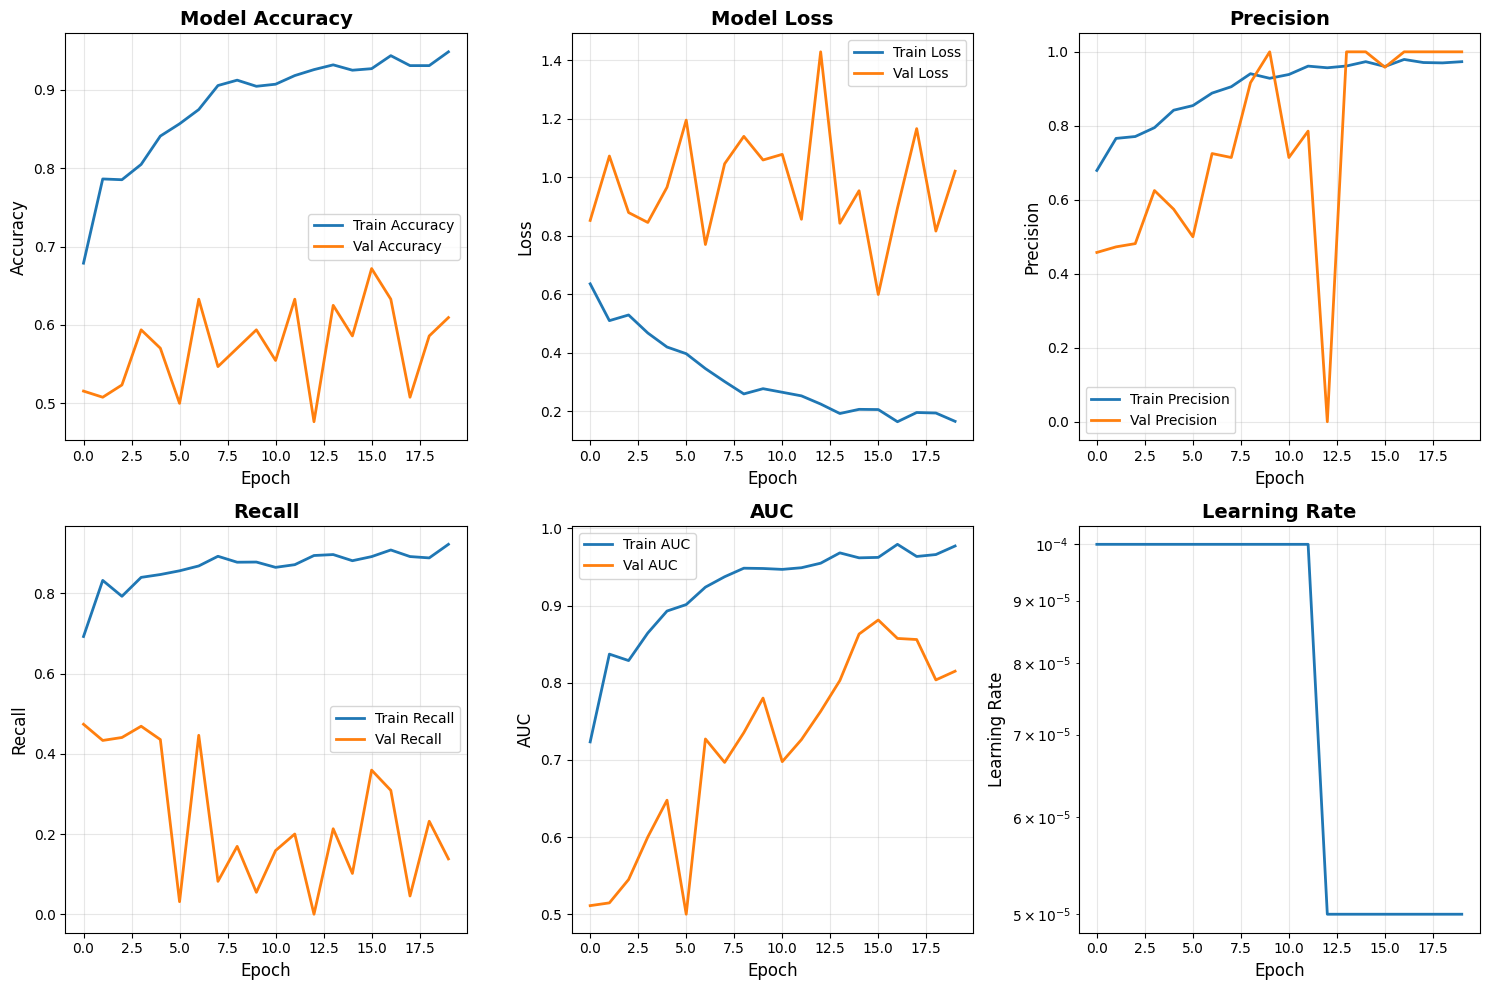

In [13]:
plot_training_history(history)

In [14]:
test_results = model.evaluate(test_generator)

213/213 [==============================] - 76s 348ms/step - loss: 0.9746 - accuracy: 0.4735 - precision_1: 0.4741 - recall_1: 0.9975 - auc: 0.4384


In [15]:
print(f"\nTest Results:")
print(f"Loss: {test_results[0]:.4f}")
print(f"Accuracy: {test_results[1]:.4f}")
print(f"Precision: {test_results[2]:.4f}")
print(f"Recall: {test_results[3]:.4f}")
print(f"AUC: {test_results[4]:.4f}")


Test Results:
Loss: 0.9746
Accuracy: 0.4735
Precision: 0.4741
Recall: 0.9975
AUC: 0.4384


In [22]:
FRAMES_PER_VIDEO = 10
model = create_model()
print("\nStarting training...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=callbacks,
    validation_steps=32,
    steps_per_epoch=256
)


Starting training...
Epoch 1/10
256/256 [==============================] - 231s 878ms/step - loss: 0.6634 - accuracy: 0.6230 - precision_5: 0.6252 - recall_5: 0.6397 - auc: 0.6802 - val_loss: 0.8233 - val_accuracy: 0.5391 - val_precision_5: 0.5000 - val_recall_5: 0.5424 - val_auc: 0.5617 - lr: 1.0000e-04
Epoch 2/10
256/256 [==============================] - 224s 874ms/step - loss: 0.5356 - accuracy: 0.7773 - precision_5: 0.7589 - recall_5: 0.8040 - auc: 0.8162 - val_loss: 0.9980 - val_accuracy: 0.4688 - val_precision_5: 0.4211 - val_recall_5: 0.2581 - val_auc: 0.5340 - lr: 1.0000e-04
Epoch 3/10
256/256 [==============================] - 224s 873ms/step - loss: 0.5082 - accuracy: 0.7855 - precision_5: 0.7700 - recall_5: 0.8052 - auc: 0.8361 - val_loss: 0.9195 - val_accuracy: 0.5938 - val_precision_5: 0.5185 - val_recall_5: 0.5185 - val_auc: 0.5713 - lr: 1.0000e-04
Epoch 4/10
256/256 [==============================] - 223s 872ms/step - loss: 0.4518 - accuracy: 0.8296 - precision_5: 0.81

In [23]:
 model.save('Threed_CNN_Deepfake.keras')

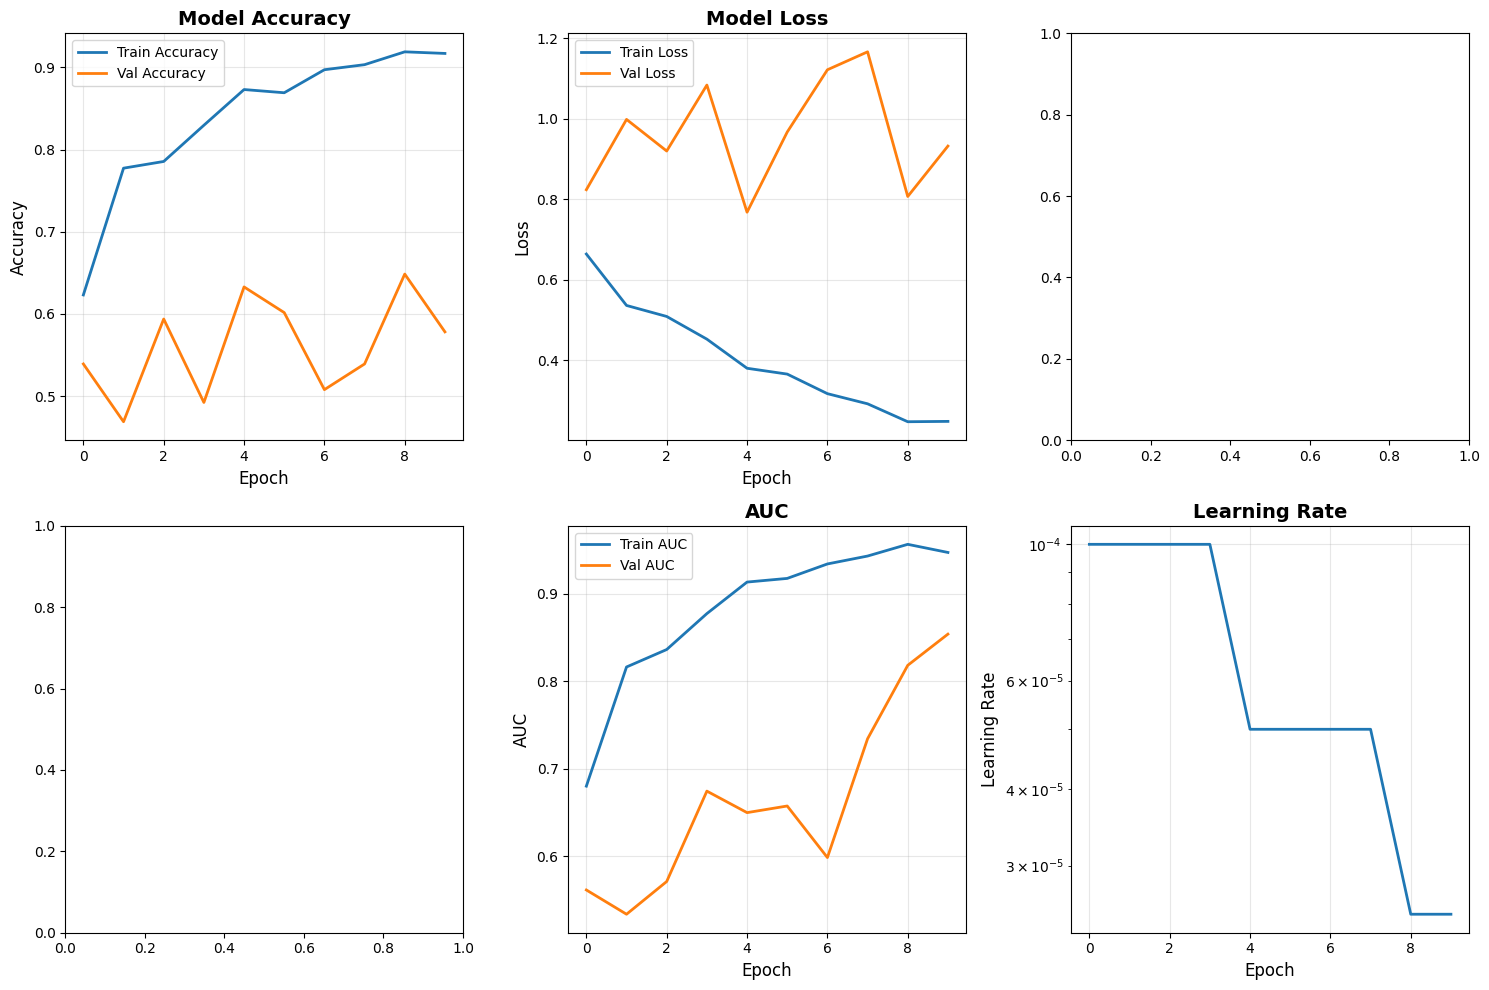

In [27]:
plot_training_history(history)

In [28]:
test_results = model.evaluate(test_generator)
print(f"\nTest Results:")
print(f"Loss: {test_results[0]:.4f}")
print(f"Accuracy: {test_results[1]:.4f}")
print(f"Precision: {test_results[2]:.4f}")
print(f"Recall: {test_results[3]:.4f}")
print(f"AUC: {test_results[4]:.4f}")

213/213 [==============================] - 75s 348ms/step - loss: 0.8129 - accuracy: 0.6266 - precision_5: 1.0000 - recall_5: 0.2134 - auc: 0.8602

Test Results:
Loss: 0.8129
Accuracy: 0.6266
Precision: 1.0000
Recall: 0.2134
AUC: 0.8602


In [30]:
test_generator = FrameSequenceGenerator(
    data_dir='../DeepfakeTIMIT/test_data',
    batch_size=4,
    frames_per_sequence=FRAMES_PER_VIDEO,
    img_size=(HEIGHT, WIDTH),
    shuffle=False,
    is_train=False,
    overlap=0  # Без перекрытия для теста
)
test_results = model.evaluate(test_generator)
print(f"\nTest Results:")
print(f"Loss: {test_results[0]:.4f}")
print(f"Accuracy: {test_results[1]:.4f}")
print(f"Precision: {test_results[2]:.4f}")
print(f"Recall: {test_results[3]:.4f}")
print(f"AUC: {test_results[4]:.4f}")

Found 10000 real images
Found 10000 fake images
Found 2000 sequences
Real: 1000
Fake: 1000
500/500 [==============================] - 237s 364ms/step - loss: 1.1530 - accuracy: 0.4995 - precision_5: 0.0000e+00 - recall_5: 0.0000e+00 - auc: 0.8111

Test Results:
Loss: 1.1530
Accuracy: 0.4995
Precision: 0.0000
Recall: 0.0000
AUC: 0.8111


In [17]:
FRAMES_PER_VIDEO = 10
spe=
for i in range(6):
    model = create_model()
    train_generator = FrameSequenceGenerator(
        data_dir='../balanced_data/train',
        batch_size=4,
        frames_per_sequence=FRAMES_PER_VIDEO,
        img_size=(HEIGHT, WIDTH),
        shuffle=True,
        is_train=True,
        overlap=OVERLAP
    )
        
    # Для тестирования
    test_generator = FrameSequenceGenerator(
        data_dir='../balanced_data/test',
        batch_size=4,
        frames_per_sequence=FRAMES_PER_VIDEO,
        img_size=(HEIGHT, WIDTH),
        shuffle=True,
        is_train=False,
        overlap=0  # Без перекрытия для теста
    )
    print("Frames per video = ", FRAMES_PER_VIDEO)
    print("\nStarting training...")
    history = model.fit(
        train_generator,
        epochs=5,
        validation_data=test_generator,
        callbacks=callbacks,
        validation_steps=32,
        steps_per_epoch=256
    )
    test_results = model.evaluate(test_generator)
    print(f"\nTest Results:")
    print(f"Loss: {test_results[0]:.4f}")
    print(f"Accuracy: {test_results[1]:.4f}")
    print(f"Precision: {test_results[2]:.4f}")
    print(f"Recall: {test_results[3]:.4f}")
    print(f"AUC: {test_results[4]:.4f}")
    FRAMES_PER_VIDEO = FRAMES_PER_VIDEO + 10

Found 15777 real images
Found 16000 fake images
Found 3177 sequences
Real: 1577
Fake: 1600
Found 4469 real images
Found 4037 fake images
Found 849 sequences
Real: 446
Fake: 403
Frames per video =  10

Starting training...
Epoch 1/5
256/256 [==============================] - 232s 881ms/step - loss: 0.6400 - accuracy: 0.6836 - precision_2: 0.6726 - recall_2: 0.7322 - auc: 0.7200 - val_loss: 0.9800 - val_accuracy: 0.4453 - val_precision_2: 0.3077 - val_recall_2: 0.2143 - val_auc: 0.3770 - lr: 1.0000e-04
Epoch 2/5
256/256 [==============================] - 225s 877ms/step - loss: 0.5514 - accuracy: 0.7551 - precision_2: 0.7284 - recall_2: 0.8114 - auc: 0.8040 - val_loss: 1.1497 - val_accuracy: 0.4531 - val_precision_2: 0.4848 - val_recall_2: 0.2319 - val_auc: 0.5370 - lr: 1.0000e-04
Epoch 3/5
256/256 [==============================] - 225s 878ms/step - loss: 0.4674 - accuracy: 0.8027 - precision_2: 0.7748 - recall_2: 0.8535 - auc: 0.8627 - val_loss: 1.0845 - val_accuracy: 0.5078 - val_prec

ResourceExhaustedError: Graph execution error:

OOM when allocating tensor with shape[4,30,56,56,32] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc
	 [[{{node model_4/residual_main_17/sequential_70/conv2_plus1d_39/sequential_68/conv3d_79/BiasAdd-0-1-TransposeNCDHWToNDHWC-LayoutOptimizer}}]]
Hint: If you want to see a list of allocated tensors when OOM happens, add report_tensor_allocations_upon_oom to RunOptions for current allocation info. This isn't available when running in Eager mode.
 [Op:__inference_train_function_117731]

In [ ]:
FRAMES_PER_VIDEO = 10
for i in range(6):
    model = create_model()
    train_generator = FrameSequenceGenerator(
        data_dir='../balanced_data/train',
        batch_size=4,
        frames_per_sequence=FRAMES_PER_VIDEO,
        img_size=(HEIGHT, WIDTH),
        shuffle=True,
        is_train=True,
        overlap=OVERLAP
    )
        
    # Для тестирования
    test_generator = FrameSequenceGenerator(
        data_dir='../balanced_data/test',
        batch_size=4,
        frames_per_sequence=FRAMES_PER_VIDEO,
        img_size=(HEIGHT, WIDTH),
        shuffle=True,
        is_train=False,
        overlap=0  # Без перекрытия для теста
    )
    print("Frames per video = ", FRAMES_PER_VIDEO)
    print("\nStarting training...")
    history = model.fit(
        train_generator,
        epochs=10,
        validation_data=test_generator,
        callbacks=callbacks,
        validation_steps=32,
        steps_per_epoch=256
    )
    test_results = model.evaluate(test_generator)
    print(f"\nTest Results:")
    print(f"Loss: {test_results[0]:.4f}")
    print(f"Accuracy: {test_results[1]:.4f}")
    print(f"Precision: {test_results[2]:.4f}")
    print(f"Recall: {test_results[3]:.4f}")
    print(f"AUC: {test_results[4]:.4f}")
    FRAMES_PER_VIDEO = FRAMES_PER_VIDEO + 10